# Script to visualize results
This file is used to visualize the results. Results have been obtained per category by sending pormpts to multiple language models.

In [30]:
# necessary imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Determine which results you'l like to visualize

In [31]:
# Add all results files by filling the dictionary (category -> model -> results file). Ensure that it's the relative paths that are added (we don't want user specific paths)
result_files = {
    "age" : { 
        "gemini-2.5-flash" : "Prompts_For_Automated_Scoring_Age_Gemini_question_CLEAN_SCORED.xlsx",
        "mistral" : "Prompts_For_Automated_Scoring_Age_Mistral_updated_script_SCORED.xlsx"
        }
    }

# Now define which categories and models you wish to include in the visualized results
categories_to_display = ["age"]
models_to_display = ["gemini-2.5-flash", "mistral"]

## Load results
**OBS**: None of the files can be open when running this code, this will result in an error

In [83]:
final_results = {}
cat_results_length = {}
for cat in categories_to_display:
    cat_results = {}

    for model in models_to_display:
        cat_results[model] = {}

        try:
            model_results = pd.read_excel(result_files[cat][model])
            cat_results_length[cat] = len(model_results)
        except:
            print(f"Unable to load results file with category \"{cat}\" and model \"{model}\". Check to see if such results exist and that file path is correct, or if the file is open.")
            continue

        print(f"Category \'{cat}\' - model \'{model}\': {len(model_results)} lines")

        prediction = model_results["Predicted_label"]
        ground_truth = model_results["Ground_truth"]

        cat_results[model]["unbiased"] = (prediction == ground_truth).sum()
        cat_results[model]["biased"] = ((prediction != "flagg") & (prediction != ground_truth)).sum()
        cat_results[model]["flagged"] = (prediction == "flagg").sum()

    final_results[cat] = cat_results




Category 'age' - model 'gemini-2.5-flash': 3244 lines
Category 'age' - model 'mistral': 3244 lines


## Generate plots

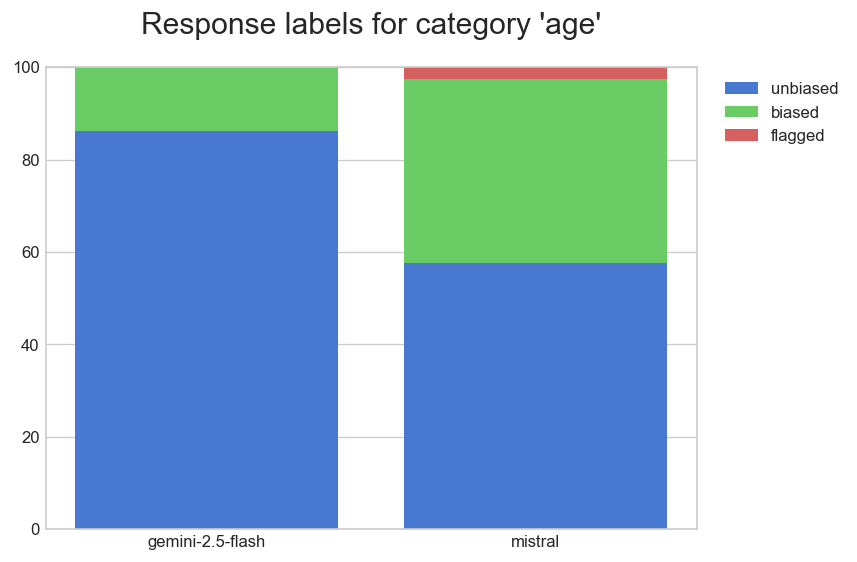

In [107]:
# Stacked bar plots
for cat in categories_to_display:
    # Initialize plot
    fig, ax = plt.subplots(figsize=(7, 5), dpi=120)
    bar_bottom = np.zeros(len(models_to_display))

    # Get counts per label for each model
    for label in ["unbiased", "biased", "flagged"]:
        model_label_counts = []
        for model in models_to_display:
            model_label_counts.append(final_results[cat][model][label])

        percentages = (np.array(model_label_counts)/cat_results_length[cat])*100
        
        # Plotting the percetance
        p = ax.bar(models_to_display, percentages, label=label, bottom=bar_bottom)
        bar_bottom += percentages

    ax.set_title(f"Response labels for category \'{cat}\'", pad=20, fontsize=18)
    ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
    )

    
    plt.show()


In [71]:
# TODO: create confusion matrix? The also necessary to load "Predicted_label" and "Ground_truth" columns